<a href="https://colab.research.google.com/github/debasishghosh-lab/Digit_Classifier/blob/master/digitClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

In [19]:
with zipfile.ZipFile('/content/Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [20]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/Dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 127 files belonging to 10 classes.
Using 102 files for training.
Found 127 files belonging to 10 classes.
Using 25 files for validation.


In [21]:
class_names = train_data.class_names

print("Classes:")
print(class_names)

Classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [22]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_data = train_data.map(
    lambda x, y: (preprocess_input(x), y)
)

val_data = val_data.map(
    lambda x, y: (preprocess_input(x), y)
)

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

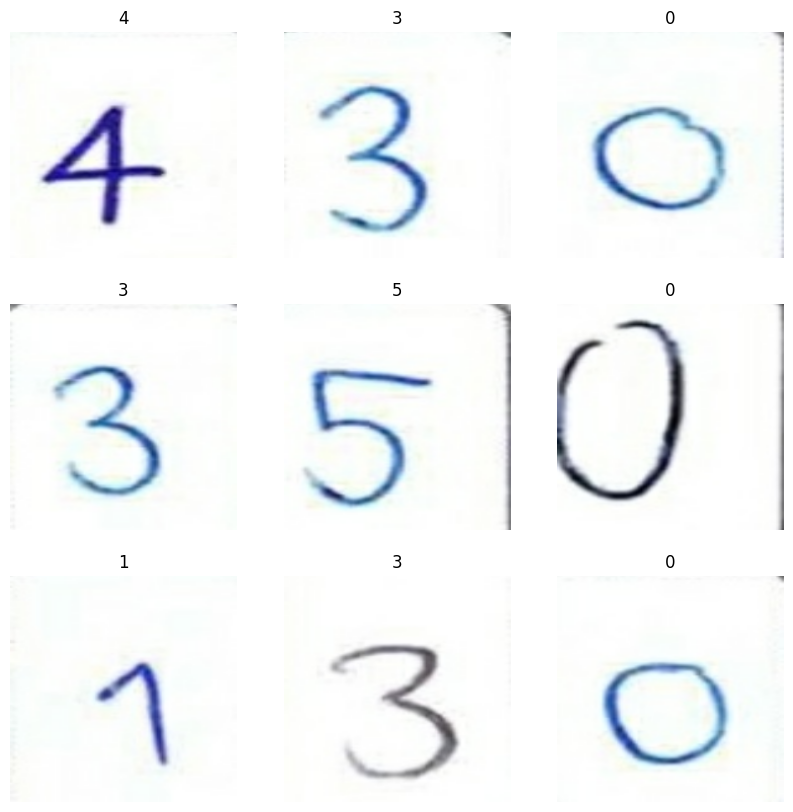

In [24]:
for images, labels in train_data.take(1):

    plt.figure(figsize=(10,10))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        img = ((images[i] + 1) * 127.5).numpy().astype("uint8")

        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [25]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.0784 - loss: 2.6180 - val_accuracy: 0.4000 - val_loss: 1.9372
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3922 - loss: 1.6990 - val_accuracy: 0.3600 - val_loss: 1.8276
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5980 - loss: 1.3086 - val_accuracy: 0.5600 - val_loss: 1.4313
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7745 - loss: 1.0162 - val_accuracy: 0.6400 - val_loss: 1.1852
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8529 - loss: 0.7610 - val_accuracy: 0.6000 - val_loss: 1.0317
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8235 - loss: 0.6593 - val_accuracy: 0.6400 - val_loss: 0.8938
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9118 - loss: 0.5080 - val_accuracy: 0.7600 - val_loss: 0.7200
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9314 - loss: 0.4103 - val_accuracy: 0.8000 - val_loss: 0.6433
Epoch 9/10
4/4

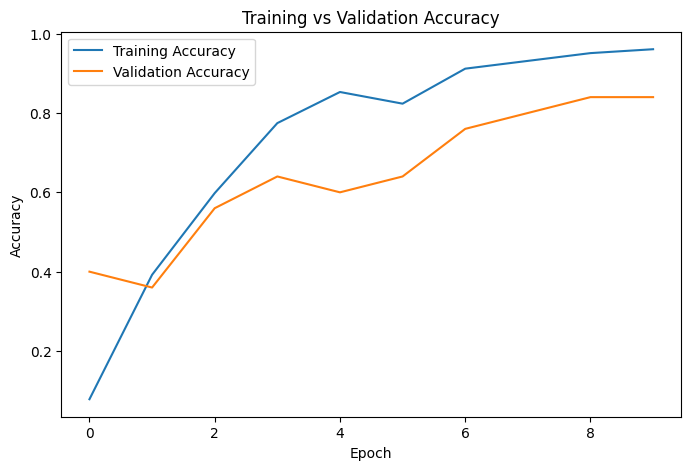

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

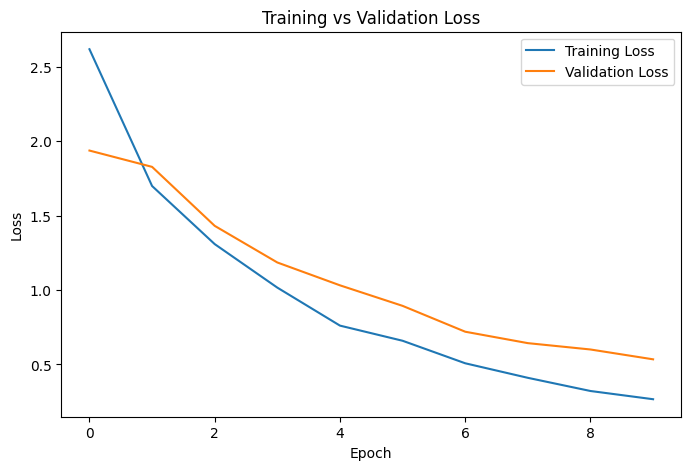

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [31]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step - accuracy: 0.8400 - loss: 0.5346
Validation Loss: 0.5345614552497864
Validation Accuracy: 0.8399999737739563


In [32]:
model.save("digit_classifier.keras")


print("Model Saved Successfully")

import pickle

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

print("Class Names Saved Successfully")

Model Saved Successfully
Class Names Saved Successfully


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np


uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path)

plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Preprocess image
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print(f"\nPredicted Digit: {predicted_class}")
print(f"Confidence: {confidence*100:.2f}%")